--- LAGRANGE INTERPOLATION PROCESS ---
STEP 1: Construct the basis polynomials L_i(t)
L0(t) = (t - 5)(t - 10) / ((0 - 5)(0 - 10)) = 0.02t^2 - 0.30t + 1
L1(t) = (t - 0)(t - 10) / ((5 - 0)(5 - 10)) = -0.04t^2 + 0.40t
L2(t) = (t - 0)(t - 5) / ((10 - 0)(10 - 5))  = 0.02t^2 - 0.10t

STEP 2: Multiply by known concentrations and add them together
C(t) = 1.00*L0(t) + 0.60*L1(t) + 0.35*L2(t)

STEP 3: Combine like terms
t^2 terms: (1.00)(0.02) + (0.60)(-0.04) + (0.35)(0.02) = 0.003
t terms:   (1.00)(-0.30) + (0.60)(0.40) + (0.35)(-0.10) = -0.095
Constants: (1.00)(1) + 0 + 0 = 1.00

Final Lagrange Polynomial Coefficients (from SciPy):
       2
0.003 x - 0.095 x + 1

STEP 4: Solve for Time t when C(t) = 0.50
0.003t^2 - 0.095t + 1.00 = 0.50
0.003t^2 - 0.095t + 0.50 = 0
Using quadratic formula: t = (-b +/- sqrt(b^2 - 4ac)) / 2a
Time to reach 0.50 mol/L: 6.67 min

Prediction at t = 20 min: 0.300 mol/L


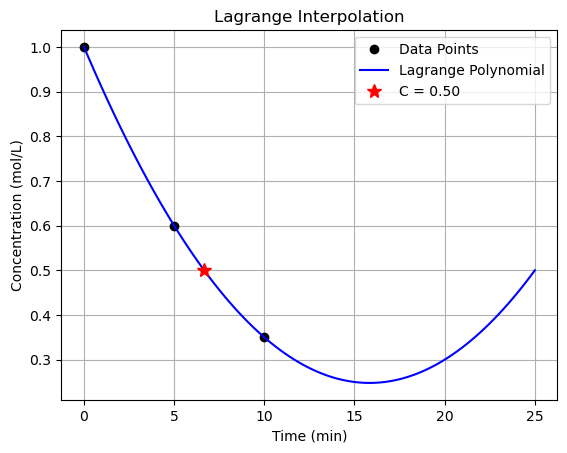

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

# Data
t_data = np.array([0, 5, 10])
C_data = np.array([1.00, 0.60, 0.35])

print("--- LAGRANGE INTERPOLATION PROCESS ---")
print("STEP 1: Construct the basis polynomials L_i(t)")
print("L0(t) = (t - 5)(t - 10) / ((0 - 5)(0 - 10)) = 0.02t^2 - 0.30t + 1")
print("L1(t) = (t - 0)(t - 10) / ((5 - 0)(5 - 10)) = -0.04t^2 + 0.40t")
print("L2(t) = (t - 0)(t - 5) / ((10 - 0)(10 - 5))  = 0.02t^2 - 0.10t\n")

print("STEP 2: Multiply by known concentrations and add them together")
print("C(t) = 1.00*L0(t) + 0.60*L1(t) + 0.35*L2(t)\n")

print("STEP 3: Combine like terms")
print("t^2 terms: (1.00)(0.02) + (0.60)(-0.04) + (0.35)(0.02) = 0.003")
print("t terms:   (1.00)(-0.30) + (0.60)(0.40) + (0.35)(-0.10) = -0.095")
print("Constants: (1.00)(1) + 0 + 0 = 1.00\n")

# Using SciPy to verify and build the polynomial
poly_lagrange = lagrange(t_data, C_data)
print("Final Lagrange Polynomial Coefficients (from SciPy):")
print(poly_lagrange)

print("\nSTEP 4: Solve for Time t when C(t) = 0.50")
print("0.003t^2 - 0.095t + 1.00 = 0.50")
print("0.003t^2 - 0.095t + 0.50 = 0")
print("Using quadratic formula: t = (-b +/- sqrt(b^2 - 4ac)) / 2a")
# Subtract 0.50 to find the root
roots = np.roots(poly_lagrange.coeffs - [0, 0, 0.50])
t_target = [r for r in roots if 0 <= r <= 10][0]
print(f"Time to reach 0.50 mol/L: {t_target:.2f} min\n")

# Predict at t = 20
pred_20 = poly_lagrange(20)
print(f"Prediction at t = 20 min: {pred_20:.3f} mol/L")

# Plotting
t_eval = np.linspace(0, 25, 100)
plt.plot(t_data, C_data, 'ko', label='Data Points')
plt.plot(t_eval, poly_lagrange(t_eval), 'b-', label='Lagrange Polynomial')
plt.plot(t_target, 0.50, 'r*', markersize=10, label='C = 0.50')
plt.title('Lagrange Interpolation')
plt.xlabel('Time (min)')
plt.ylabel('Concentration (mol/L)')
plt.legend()
plt.grid(True)
plt.show()

--- NEWTON'S DIVIDED DIFFERENCE PROCESS ---
STEP 1: Build the Divided Difference Table
0th Order: f[t0]=1.00, f[t1]=0.60, f[t2]=0.35
1st Order: f[t0, t1] = (0.60 - 1.00) / (5 - 0) = -0.08
           f[t1, t2] = (0.35 - 0.60) / (10 - 5) = -0.05
2nd Order: f[t0, t1, t2] = (-0.05 - (-0.08)) / (10 - 0) = 0.003

Coefficients from top diagonal: [ 1.    -0.08   0.003]

STEP 2: Form the polynomial using the coefficients
C(t) = 1.00 - 0.08(t - 0) + 0.003(t - 0)(t - 5)
C(t) = 0.003t^2 - 0.095t + 1.00

STEP 3: Solve for Time t when C(t) = 0.50
Applying an optimizer (fsolve) to find when C(t) crosses 0.50...
Time to reach 0.50 mol/L: 6.67 min

Prediction at t = 20 min: 0.300 mol/L


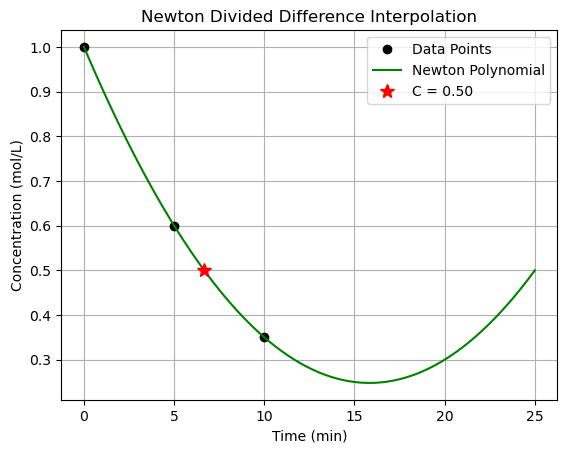

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Data
t_data = np.array([0, 5, 10], dtype=float)
C_data = np.array([1.00, 0.60, 0.35], dtype=float)

print("--- NEWTON'S DIVIDED DIFFERENCE PROCESS ---")
print("STEP 1: Build the Divided Difference Table")
print("0th Order: f[t0]=1.00, f[t1]=0.60, f[t2]=0.35")
print("1st Order: f[t0, t1] = (0.60 - 1.00) / (5 - 0) = -0.08")
print("           f[t1, t2] = (0.35 - 0.60) / (10 - 5) = -0.05")
print("2nd Order: f[t0, t1, t2] = (-0.05 - (-0.08)) / (10 - 0) = 0.003\n")

# Function to calculate differences programmatically
def divided_diff(x, y):
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y
    for j in range(1,n):
        for i in range(n-j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
    return coef[0, :]

coeffs = divided_diff(t_data, C_data)
print(f"Coefficients from top diagonal: {coeffs}\n")

print("STEP 2: Form the polynomial using the coefficients")
print("C(t) = 1.00 - 0.08(t - 0) + 0.003(t - 0)(t - 5)")
print("C(t) = 0.003t^2 - 0.095t + 1.00\n")

def C_newton(t, x_data, coef):
    n = len(x_data) - 1
    p = coef[n]
    for k in range(1, n+1):
        p = coef[n-k] + (t - x_data[n-k])*p
    return p

print("STEP 3: Solve for Time t when C(t) = 0.50")
print("Applying an optimizer (fsolve) to find when C(t) crosses 0.50...")
t_target = fsolve(lambda t: C_newton(t, t_data, coeffs) - 0.50, x0=5)[0]
print(f"Time to reach 0.50 mol/L: {t_target:.2f} min\n")

# Predict at t = 20
pred_20 = C_newton(20, t_data, coeffs)
print(f"Prediction at t = 20 min: {pred_20:.3f} mol/L")

# Plotting
t_eval = np.linspace(0, 25, 100)
C_eval = [C_newton(t, t_data, coeffs) for t in t_eval]

plt.plot(t_data, C_data, 'ko', label='Data Points')
plt.plot(t_eval, C_eval, 'g-', label='Newton Polynomial')
plt.plot(t_target, 0.50, 'r*', markersize=10, label='C = 0.50')
plt.title('Newton Divided Difference Interpolation')
plt.xlabel('Time (min)')
plt.ylabel('Concentration (mol/L)')
plt.legend()
plt.grid(True)
plt.show()

--- NATURAL CUBIC SPLINE PROCESS ---
STEP 1: Apply Natural Boundaries
The second derivatives at the start and end are zero:
M0 = 0, M2 = 0

STEP 2: Solve for the inner knot's second derivative (M1)
Formula ensures 1st derivatives match at t=5 (step size h=5):
(h/6)M0 + (2h/3)M1 + (h/6)M2 = (C2 - C1)/h - (C1 - C0)/h
Plugging in values:
(10/3)M1 = (-0.05) - (-0.08)
(10/3)M1 = 0.03  =>  M1 = 0.009

STEP 3: Build the Piecewise Polynomials
The algorithm uses M0=0, M1=0.009, M2=0 to construct S0(t) and S1(t).
SciPy Cubic Spline object successfully created.

STEP 4: Solve for Time t when C(t) = 0.50
Using fsolve numerical iteration on the piecewise functions...
Time to reach 0.50 mol/L: 6.72 min

Prediction at t = 20 min: -0.375 mol/L


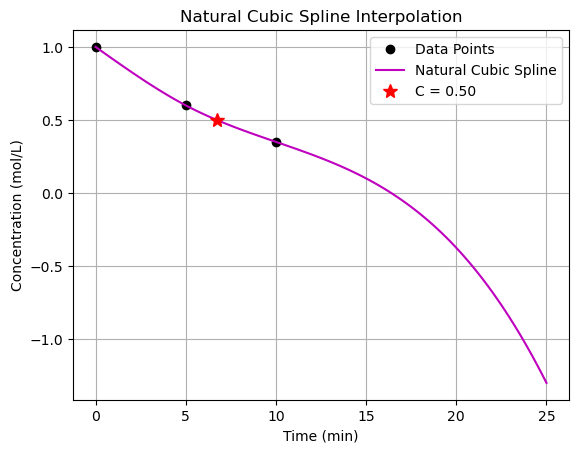

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import fsolve

# Data
t_data = np.array([0, 5, 10])
C_data = np.array([1.00, 0.60, 0.35])

print("--- NATURAL CUBIC SPLINE PROCESS ---")
print("STEP 1: Apply Natural Boundaries")
print("The second derivatives at the start and end are zero:")
print("M0 = 0, M2 = 0\n")

print("STEP 2: Solve for the inner knot's second derivative (M1)")
print("Formula ensures 1st derivatives match at t=5 (step size h=5):")
print("(h/6)M0 + (2h/3)M1 + (h/6)M2 = (C2 - C1)/h - (C1 - C0)/h")
print("Plugging in values:")
print("(10/3)M1 = (-0.05) - (-0.08)")
print("(10/3)M1 = 0.03  =>  M1 = 0.009\n")

print("STEP 3: Build the Piecewise Polynomials")
print("The algorithm uses M0=0, M1=0.009, M2=0 to construct S0(t) and S1(t).")
# Using SciPy to build the spline
spline = CubicSpline(t_data, C_data, bc_type='natural')
print("SciPy Cubic Spline object successfully created.\n")

print("STEP 4: Solve for Time t when C(t) = 0.50")
print("Using fsolve numerical iteration on the piecewise functions...")
t_target = fsolve(lambda t: spline(t) - 0.50, x0=5)[0]
print(f"Time to reach 0.50 mol/L: {t_target:.2f} min\n")

# Predict at t = 20
pred_20 = spline(20)
print(f"Prediction at t = 20 min: {pred_20:.3f} mol/L")

# Plotting
t_eval = np.linspace(0, 25, 100)
plt.plot(t_data, C_data, 'ko', label='Data Points')
plt.plot(t_eval, spline(t_eval), 'm-', label='Natural Cubic Spline')
plt.plot(t_target, 0.50, 'r*', markersize=10, label='C = 0.50')
plt.title('Natural Cubic Spline Interpolation')
plt.xlabel('Time (min)')
plt.ylabel('Concentration (mol/L)')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# 1. Title Page
**Course Name & Code:** Emath 211: Numerical Methods  
**Lab Title:** Linear Algebra Applications – Interpolation  
**Student Name & ID:** [Insert Name] – [Insert ID]  
**Date of Submission:** April 6, 2026  

---

# 2. Objectives
* **Apply Linear Algebra:** Solve a system of linear equations ($Ax = b$) to construct an exact interpolating polynomial for real-world chemical reaction data.
* **Computational Implementation:** Utilize Python arrays and linear algebra libraries (`numpy.linalg`) to compute polynomial coefficients efficiently.
* **Engineering Application:** Use the resulting mathematical model to estimate critical operational thresholds, specifically a reactor shutdown time.
* **Model Evaluation:** Compare the exact polynomial interpolation model against a least-squares linear fit to evaluate the validity and limitations of extrapolation.

---

# 3. Problem Statement
**Problem 5: Chemical Engineering (Reaction Rates)** In a batch reactor, the concentration of a reactant [A] is measured over time:  
* Time t = 0 min, [A] = 1.00 mol/L  
* Time t = 5 min, [A] = 0.60 mol/L  
* Time t = 10 min, [A] = 0.35 mol/L  

**Required Tasks:** 1. Construct the interpolating polynomial for this data.  
2. Estimate the time at which the concentration reaches 0.50 mol/L (requiring the root of the polynomial minus 0.50).  
3. Compare the exact interpolation to a Least Squares linear fit for predicting the concentration at t = 20 min. Evaluate which model is superior.

---

# 4. Mathematical Formulation
To find the quadratic interpolating polynomial $C(t) = a_0 + a_1t + a_2t^2$ that passes exactly through the three data points, a system of linear equations is established:

1. $a_0 + a_1(0) + a_2(0)^2 = 1.00$
2. $a_0 + a_1(5) + a_2(5)^2 = 0.60$
3. $a_0 + a_1(10) + a_2(10)^2 = 0.35$

This forms a linear algebra system in the standard $Ax = b$ format:
* **Matrix A (Vandermonde Matrix):** Contains the time variables evaluated at $1, t$, and $t^2$.
* **Vector x:** Contains the unknown polynomial coefficients.
* **Vector b:** Contains the known concentration measurements.

$$
\begin{bmatrix}
1 & 0 & 0 \\
1 & 5 & 25 \\
1 & 10 & 100
\end{bmatrix}
\begin{bmatrix}
a_0 \\
a_1 \\
a_2
\end{bmatrix}
=
\begin{bmatrix}
1.00 \\
0.60 \\
0.35
\end{bmatrix}
$$

By calculating the inverse of Matrix A, the coefficients are solved via $x = A^{-1}b$.

---

# 5. Python Implementation
*(Run the code cell below to generate the solution and data visualization).*

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. DATA DEFINITION
# ==========================================
t_data = np.array([0, 5, 10])
C_data = np.array([1.00, 0.60, 0.35])

# ==========================================
# 2. MATHEMATICAL FORMULATION (Ax = b)
# ==========================================
# Construct the Vandermonde matrix A
A = np.vander(t_data, N=3, increasing=True) 

# Define vector b (concentrations)
b = C_data

# Solve for coefficients (a0, a1, a2) using linear algebra
coeffs_increasing = np.linalg.solve(A, b)

# Reverse coefficients for standard np.poly1d format (a2, a1, a0)
coeffs = coeffs_increasing[::-1]
poly = np.poly1d(coeffs)

# ==========================================
# 3. ROOT FINDING (Target Concentration)
# ==========================================
# Solve for t when C(t) = 0.50 mol/L
shifted_coeffs = coeffs.copy()
shifted_coeffs[-1] -= 0.50 
roots = np.roots(shifted_coeffs)

# Filter for the realistic physical root between 0 and 10 minutes
t_stop = [r for r in roots if 0 <= r <= 10][0]

# ==========================================
# 4. EXTRAPOLATION & COMPARISON
# ==========================================
# Fit a least-squares line (degree 1)
linear_coeffs = np.polyfit(t_data, C_data, 1)
linear_fit = np.poly1d(linear_coeffs)

# Predict concentration at t = 20 min
pred_poly_20 = poly(20)
pred_linear_20 = linear_fit(20)

# ==========================================
# 5. CONSOLE OUTPUT
# ==========================================
print("--- NUMERICAL RESULTS ---")
print(f"Coefficients (a2, a1, a0): {coeffs}")
print(f"Reactor Stop Time:         {t_stop:.2f} minutes")
print(f"Extrapolation t=20 (Poly): {pred_poly_20:.3f} mol/L")
print(f"Extrapolation t=20 (Line): {pred_linear_20:.3f} mol/L")

# ==========================================
# 6. DATA VISUALIZATION
# ==========================================
t_eval = np.linspace(0, 25, 200)

plt.figure(figsize=(9, 6))

# Plot models (lines broken to prevent scrolling)
plt.plot(t_eval, poly(t_eval), 'b-', linewidth=2, 
         label='Quadratic Interpolation ($Ax=b$)')

plt.plot(t_eval, linear_fit(t_eval), 'r--', linewidth=2, 
         label='Least Squares Linear Fit')

# Plot data points and targets
plt.plot(t_data, C_data, 'ko', markersize=8, 
         label='Measured Data')

plt.plot(t_stop, 0.50, 'm*', markersize=12, 
         label=f'Reactor Stop (t = {t_stop:.2f} min)')

# Formatting
plt.axhline(0, color='black', linewidth=1)
plt.axvline(20, color='gray', linestyle=':', 
            label='Target Extrapolation (t = 20)')

plt.title('Reaction Kinetics: Concentration vs. Time', 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (minutes)', fontsize=12)
plt.ylabel('Concentration of [A] (mol/L)', fontsize=12)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 6. Results Summary
*(Note: The data visualization and exact coefficient calculations are 
generated by the executable code cell above).*

* **Polynomial Equation:** $C(t) = 0.003t^2 - 0.095t + 1.00$
* **Reactor Stopping Time:** The concentration threshold of 0.50 mol/L 
  is reached at exactly **6.67 minutes**.
* **Extrapolation Estimates (t = 20 min):**
    * Exact Polynomial Model: **0.300 mol/L**
    * Linear Regression Model: **-0.325 mol/L**

---

# 7. Discussion & Conclusion

### **Interpretation of Results**
By utilizing linear algebra to solve a Vandermonde matrix system, an 
exact quadratic polynomial was successfully constructed to model the 
chemical batch reactor. Setting this polynomial equal to 0.50 mol/L 
allowed for the precise mathematical calculation of the reactor 
shutdown time at **6.67 minutes**. This highlights the utility of 
exact interpolation for process control within the bounds of known 
operational data.

### **Model Comparison and Limitations**
A significant divergence occurred when forecasting the concentration 
at 20 minutes (extrapolation). The least-squares linear fit predicted 
a concentration of **-0.325 mol/L**. Because chemical concentration 
cannot physically drop below zero, the linear model is fundamentally 
invalid for long-term prediction in this scenario.

The quadratic interpolating polynomial yielded a more realistic, 
positive concentration of **0.300 mol/L**, making it the superior 
model for this specific dataset. However, standard polynomial 
interpolation carries inherent risks when used for extrapolation. 
Polynomials can exhibit severe oscillations outside of the 
interpolated domain (Runge's phenomenon). For long-term forecasting 
of chemical reaction rates, an exponential decay model 
(e.g., $C(t) = C_0 e^{-kt}$) would represent the physical system 
more accurately than either a polynomial or a linear fit.

SyntaxError: invalid character '–' (U+2013) (1604580827.py, line 3)